In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from kneed import KneeLocator
import hdbscan

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

%matplotlib inline

📦 Датасет

Название: "Customer Segmentation" (Kaggle)

Ссылка: [Customer Segmentation Dataset](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

## 1) Загрузка и предобработка

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df = df.drop(columns=['CustomerID'])

In [4]:
df.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [5]:
df.shape

(200, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [7]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df['Gender_le'] = LabelEncoder().fit_transform(df['Gender'])
df = df.drop(columns=['Gender'])

In [9]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100),Gender_le
count,200.000000,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000,0.440000
std,13.969007,26.264721,25.823522,0.497633
min,18.000000,15.000000,1.000000,0.000000
25%,28.750000,41.500000,34.750000,0.000000
50%,36.000000,61.500000,50.000000,0.000000
75%,49.000000,78.000000,73.000000,1.000000
max,70.000000,137.000000,99.000000,1.000000


In [10]:
df.columns = ["Age", "Annual_Income", "Spending_Score", "Gender"]

In [11]:
scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [12]:
df_norm.head(5)

,Age,Annual_Income,Spending_Score,Gender
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


## 2) Разведочный анализ (EDA)

Описание:
 - Датасет содержит данные о покупательском поведении клиентов:

 - CustomerID — уникальный идентификатор клиента

 - Gender — пол

 - Age — возраст

 - Annual Income (k$) — годовой доход (в тысячах долларов)

 - Spending Score (1-100) — поведенческий балл трат (чем выше, тем больше клиент тратит)

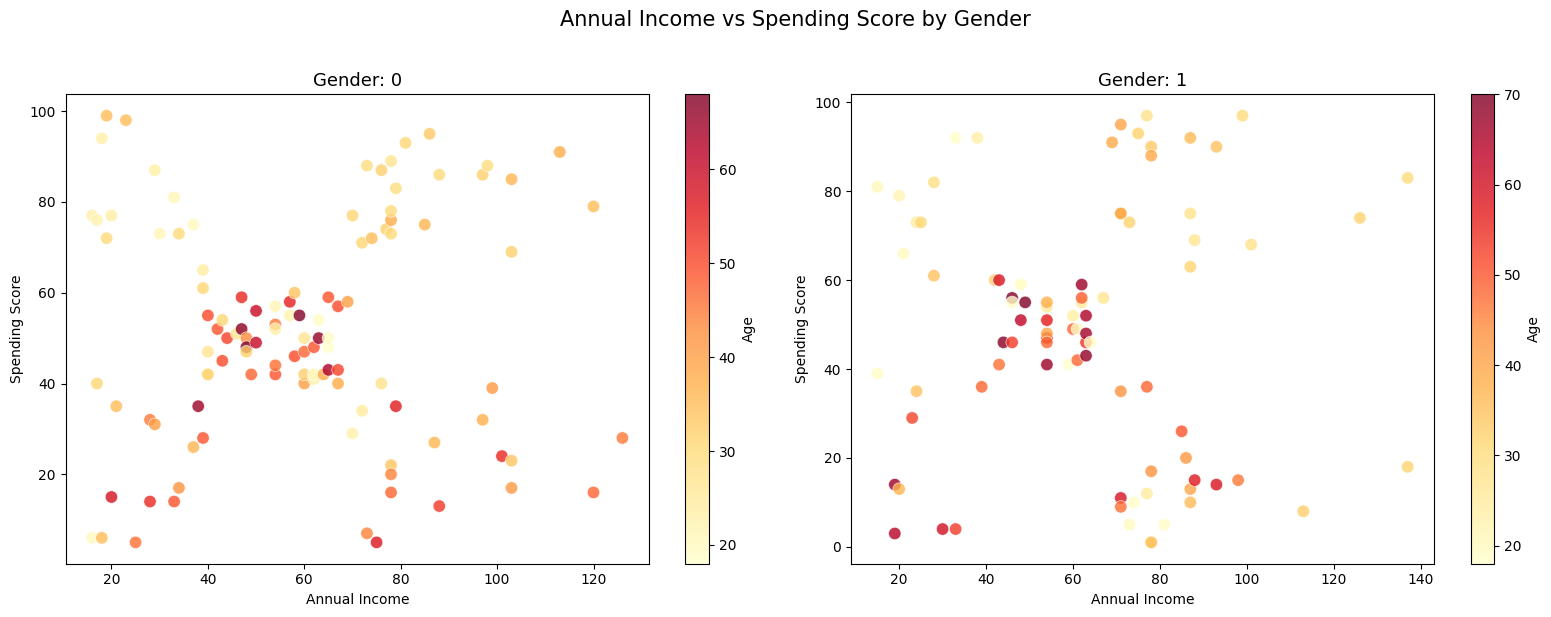

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (gender, group) in zip(axes, df.groupby("Gender")):
    sc = ax.scatter(
        group["Annual_Income"],
        group["Spending_Score"],
        c=group["Age"],
        cmap="YlOrRd",
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
        s=80
    )
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Gender: {gender}", fontsize=13)
    ax.set_xlabel("Annual Income")
    ax.set_ylabel("Spending Score")

plt.suptitle("Annual Income vs Spending Score by Gender", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

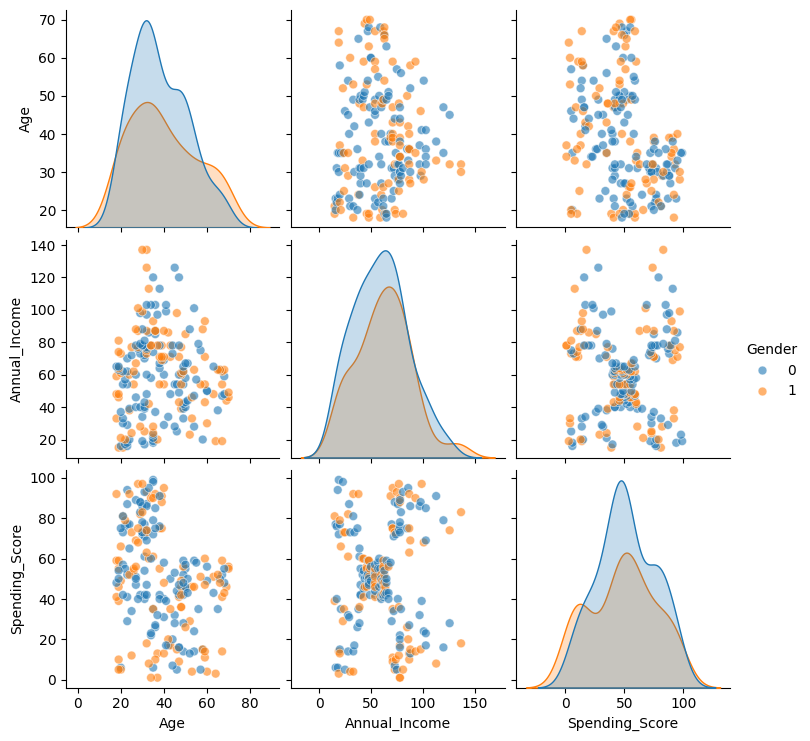

In [14]:
sns.pairplot(
    df,
    hue="Gender",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 40}
)
plt.show()


#### Быстрая проверка на выбросы (для kmeans)

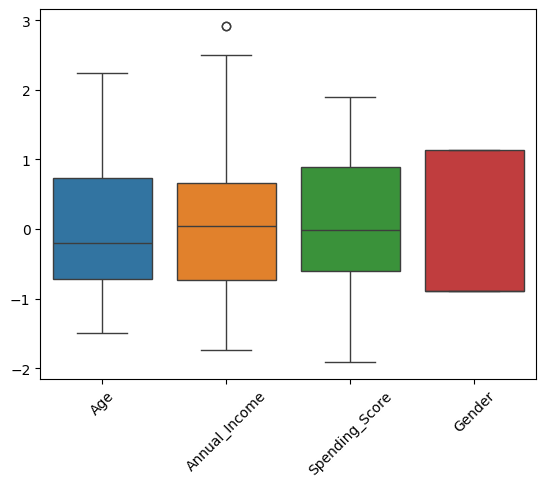

In [15]:
sns.boxplot(data=df_norm)
plt.xticks(rotation=45)
plt.show()

In [16]:
df.sort_values(by='Annual_Income', ascending=False).head(5)

,Age,Annual_Income,Spending_Score,Gender
199,30,137,83,1
198,32,137,18,1
197,32,126,74,1
196,45,126,28,0
195,35,120,79,0


(не выброс)

## 3) K-Means

In [17]:
X = df_norm

### Нахождение К класстеров методом локтя (Elbow method)

In [18]:
list_K = range(3, 11) 

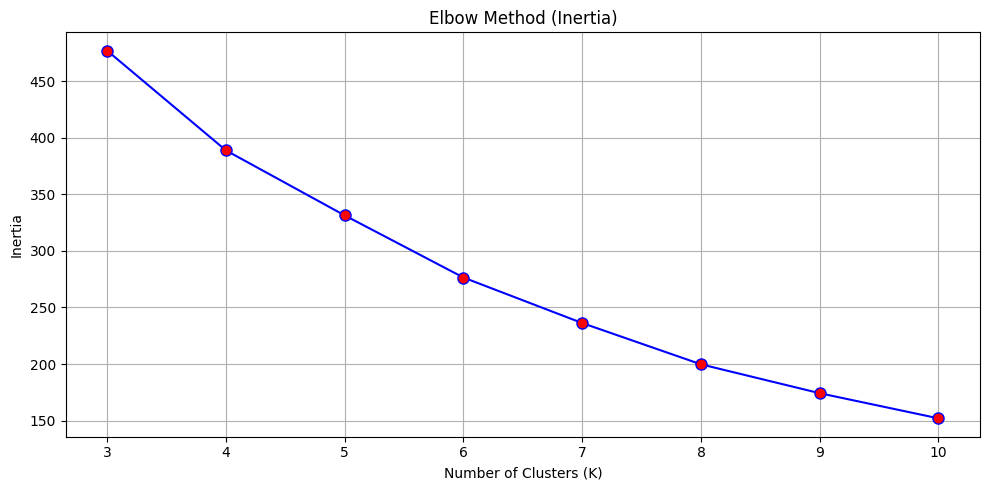

In [19]:
list_inertia = []

for K in list_K:
    model = KMeans(K, init='k-means++', random_state=42, n_init=10)
    model.fit(X)
    list_inertia.append(model.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(list_K, list_inertia, 'bo-', markerfacecolor='red', markersize=8)
ax.set_title('Elbow Method (Inertia)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.grid(True)

plt.tight_layout()
plt.show()


локтя нет)

### Нахождение К класстеров по кф силуета (Silhouette Coefficient)

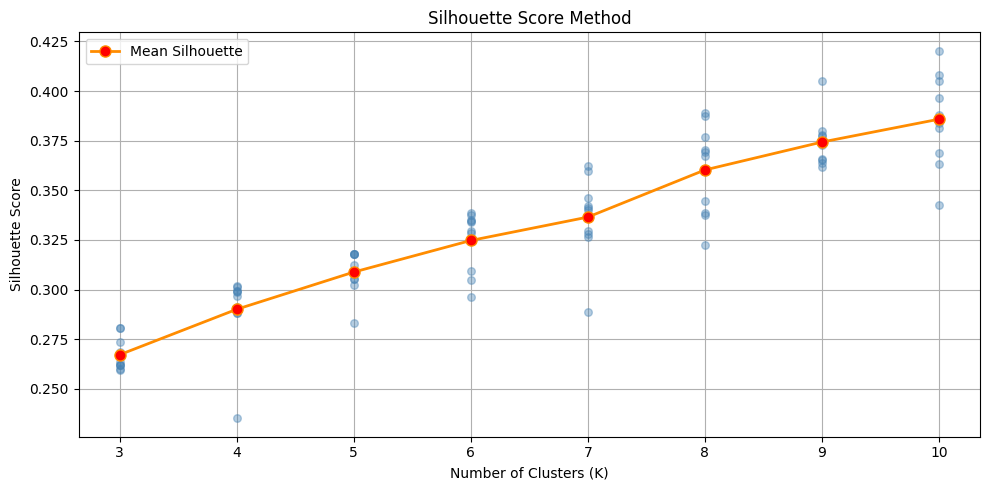

In [20]:
n_repeats = 10

all_silhouette_scores, avg_silhouette = [], []
best_silhouette_overall, best_K = -1, None

for K in list_K:
    list_silhouette_score = []
    for seed in range(n_repeats):
        model = KMeans(K, init='k-means++', random_state=seed, n_init=1)
        labels = model.fit_predict(X)
        silhouette_score_ = silhouette_score(X, labels)
        list_silhouette_score.append(silhouette_score_)

    all_silhouette_scores.append(list_silhouette_score)
    mean_sil = np.mean(list_silhouette_score)
    avg_silhouette.append(mean_sil)

    if mean_sil > best_silhouette_overall:
        best_silhouette_overall = mean_sil
        best_K = K

fig, ax = plt.subplots(figsize=(10, 5))

# Scatter: все отдельные значения silhouette для каждого K
for i, K in enumerate(list_K):
    ax.scatter([K] * n_repeats, all_silhouette_scores[i],
               color='steelblue', alpha=0.4, s=30, zorder=2)

# Line: среднее значение
ax.plot(list_K, avg_silhouette, 'o-', color='darkorange',
        markerfacecolor='red', markersize=8, linewidth=2,
        label='Mean Silhouette', zorder=3)

ax.set_title('Silhouette Score Method')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


Локтя особо не заметно, значит берем max по силуетскору

In [21]:
print(f"Оптимальное количество кластеров по Silhouette Coefficient: {best_K}")

Оптимальное количество кластеров по Silhouette Coefficient: 10


#### Обучение kmean для оптимального количество кластеров

In [22]:
model_kmeans = KMeans(best_K, init='k-means++', random_state=42)
labels_kmeans = model_kmeans.fit_predict(X)

silhouette_score_kmeans = silhouette_score(X, labels_kmeans)
db_index_kmeans = davies_bouldin_score(X, labels_kmeans)
ch_index_kmeans = calinski_harabasz_score(X, labels_kmeans)

silhouette_score_kmeans

0.42076374869477745

In [23]:
def interpretation_cluster(df):
    for cluster in sorted(df['Label'].unique()):
        subset = df[df['Label'] == cluster]
        print(f"\n--- Cluster {cluster+1} ---")
        print(f"Size: {len(subset)} customers")
        print(f"Avg Age: {subset['Age'].mean():.1f} years")
        print(f"Avg Income: ${subset['Annual_Income'].mean():.1f}k")
        print(f"Avg Spending Score: {subset['Spending_Score'].mean():.1f}")
        print(f"Avg Gender: {subset['Gender'].mean():.1f} - 1(man), 0(women)")


In [24]:
df = scaler.inverse_transform(X)

df_kmean_result = pd.DataFrame(df, columns=['Age', 'Annual_Income', 'Spending_Score', 'Gender'])
df_kmean_result['Label'] = labels_kmeans

interpretation_cluster(df_kmean_result)


--- Cluster 1 ---
Size: 26 customers
Avg Age: 58.8 years
Avg Income: $48.7k
Avg Spending Score: 39.8
Avg Gender: 1.0 - 1(man), 0(women)

--- Cluster 2 ---
Size: 24 customers
Avg Age: 25.2 years
Avg Income: $41.2k
Avg Spending Score: 60.9
Avg Gender: 1.0 - 1(man), 0(women)

--- Cluster 3 ---
Size: 14 customers
Avg Age: 41.2 years
Avg Income: $26.1k
Avg Spending Score: 20.1
Avg Gender: 0.1 - 1(man), 0(women)

--- Cluster 4 ---
Size: 21 customers
Avg Age: 32.2 years
Avg Income: $86.0k
Avg Spending Score: 81.7
Avg Gender: 0.0 - 1(man), 0(women)

--- Cluster 5 ---
Size: 26 customers
Avg Age: 54.2 years
Avg Income: $54.2k
Avg Spending Score: 49.0
Avg Gender: 0.0 - 1(man), 0(women)

--- Cluster 6 ---
Size: 19 customers
Avg Age: 38.5 years
Avg Income: $85.9k
Avg Spending Score: 14.2
Avg Gender: 1.0 - 1(man), 0(women)

--- Cluster 7 ---
Size: 25 customers
Avg Age: 28.0 years
Avg Income: $57.4k
Avg Spending Score: 47.1
Avg Gender: 0.0 - 1(man), 0(women)

--- Cluster 8 ---
Size: 18 customers
Avg

In [25]:
columns_result = ['Algoritm', 'N_clusters', 'Avg_frequens',  'Silhouette_score', 'DB-index', 'CH-index', 'Params']
df_result = pd.DataFrame(columns=columns_result)

In [26]:
def update_df_result(*args):
    tmp_series = pd.Series(args, index=df_result.columns)
    return pd.concat([df_result, tmp_series.to_frame().T], ignore_index=True)

df_result = update_df_result('kmeans', 
                            model_kmeans.n_clusters, 
                            X.shape[0]/model_kmeans.n_clusters, 
                            silhouette_score_kmeans,
                            db_index_kmeans,
                            ch_index_kmeans, 
                            model_kmeans.get_params()
                            )

In [27]:
df_result

,Algoritm,N_clusters,Avg_frequens,Silhouette_score,DB-index,CH-index,Params
0,kmeans,10,20.0,0.420764,0.833103,89.978196,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."


<Axes: xlabel='Annual_Income', ylabel='Spending_Score'>

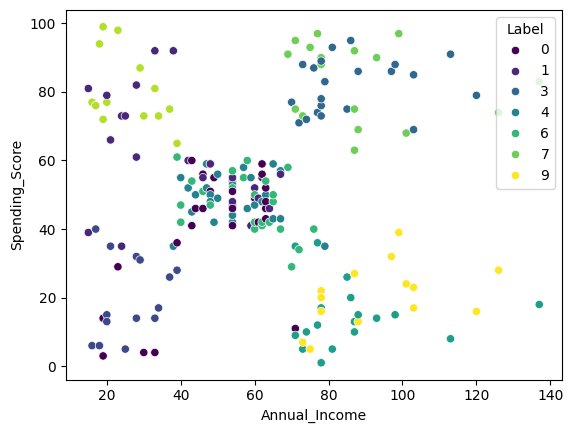

In [28]:
sns.scatterplot(
    x=df_kmean_result['Annual_Income'],
    y=df_kmean_result['Spending_Score'],
    hue=df_kmean_result['Label'],
    palette='viridis'
)

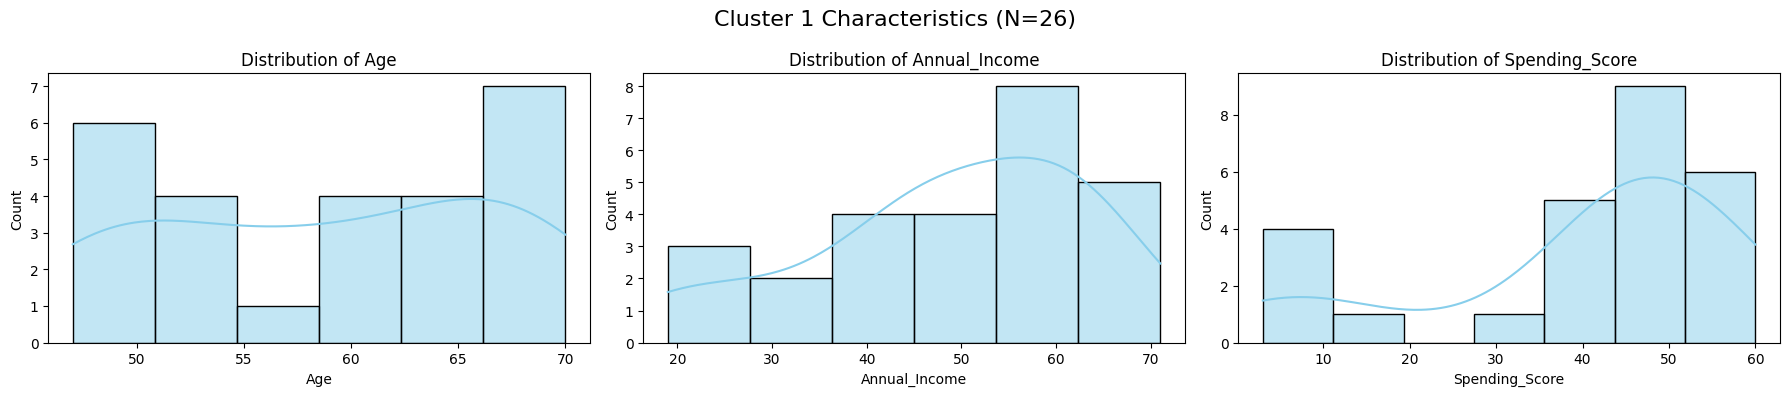

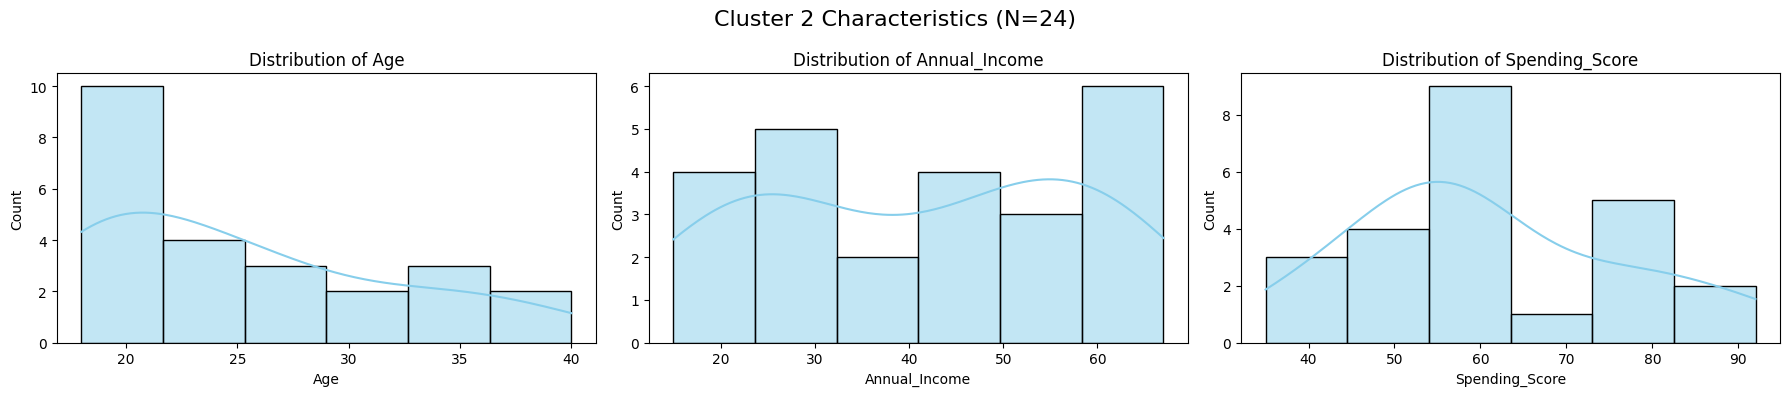

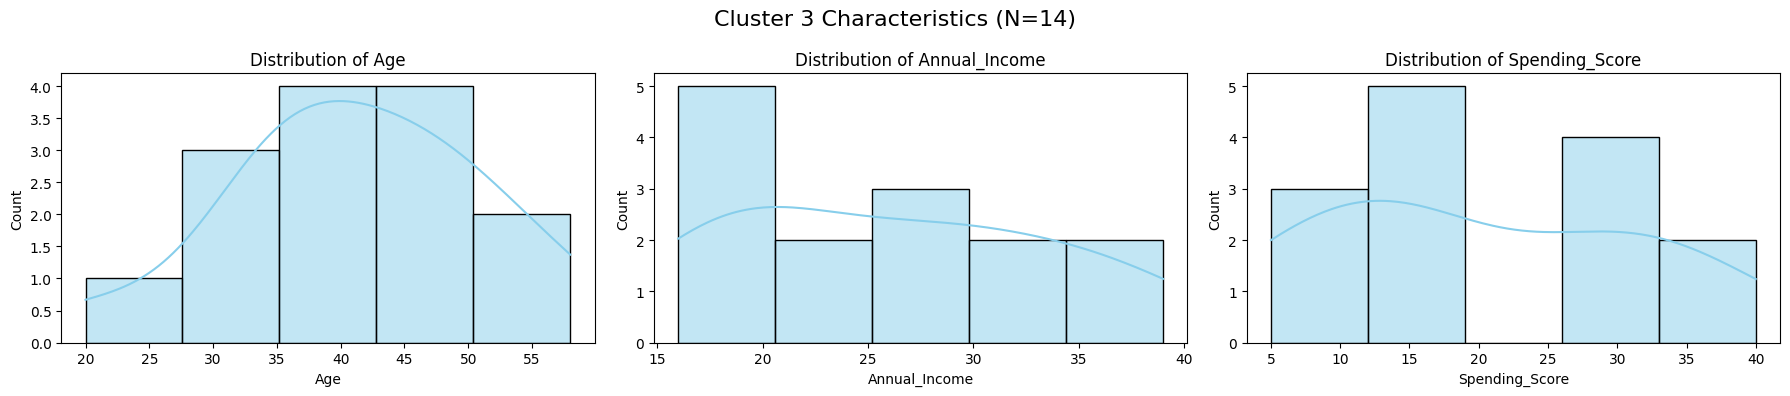

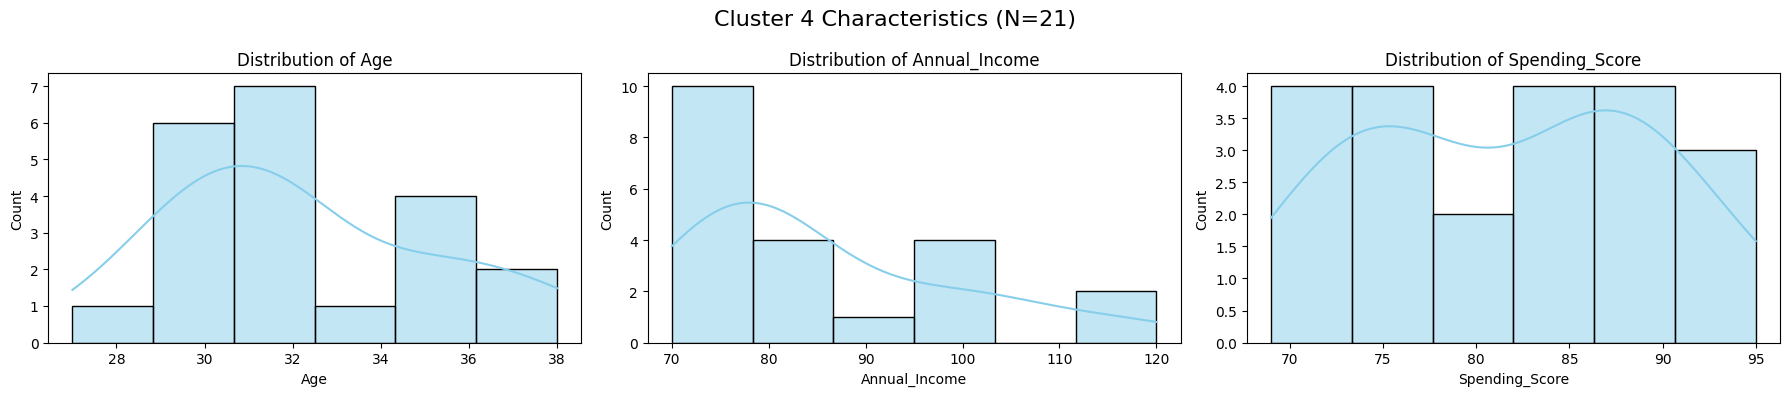

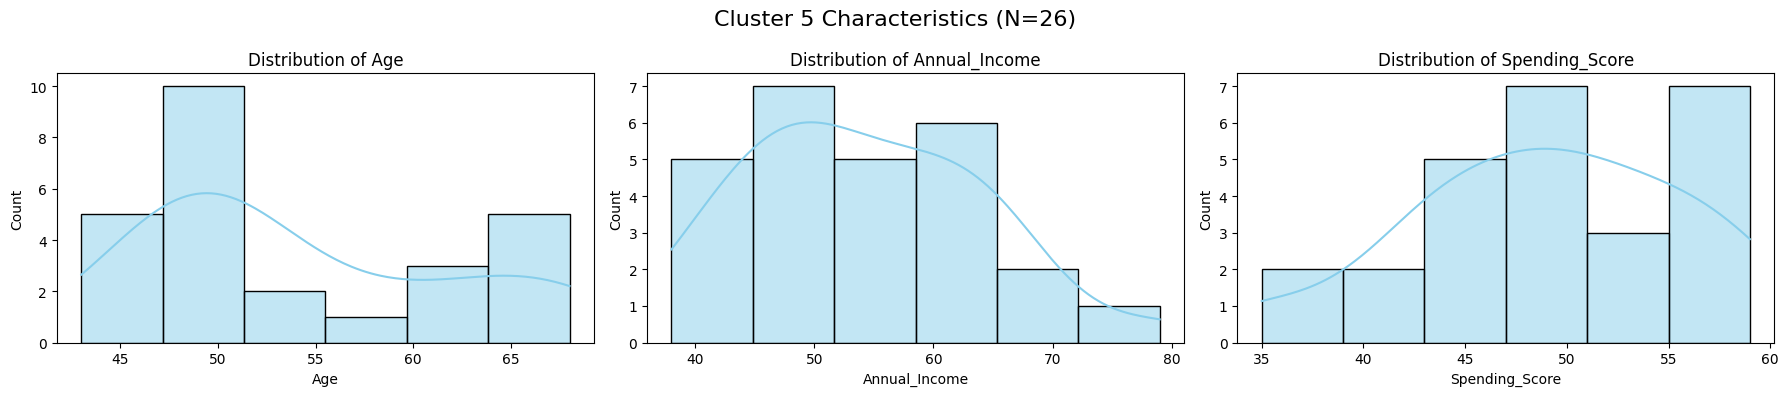

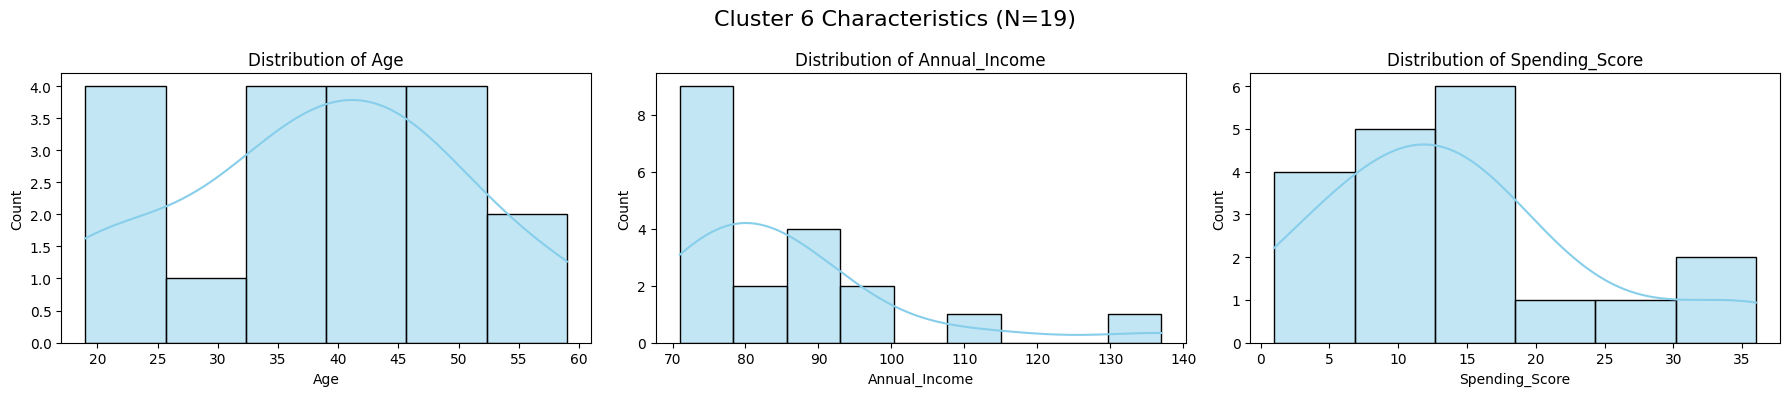

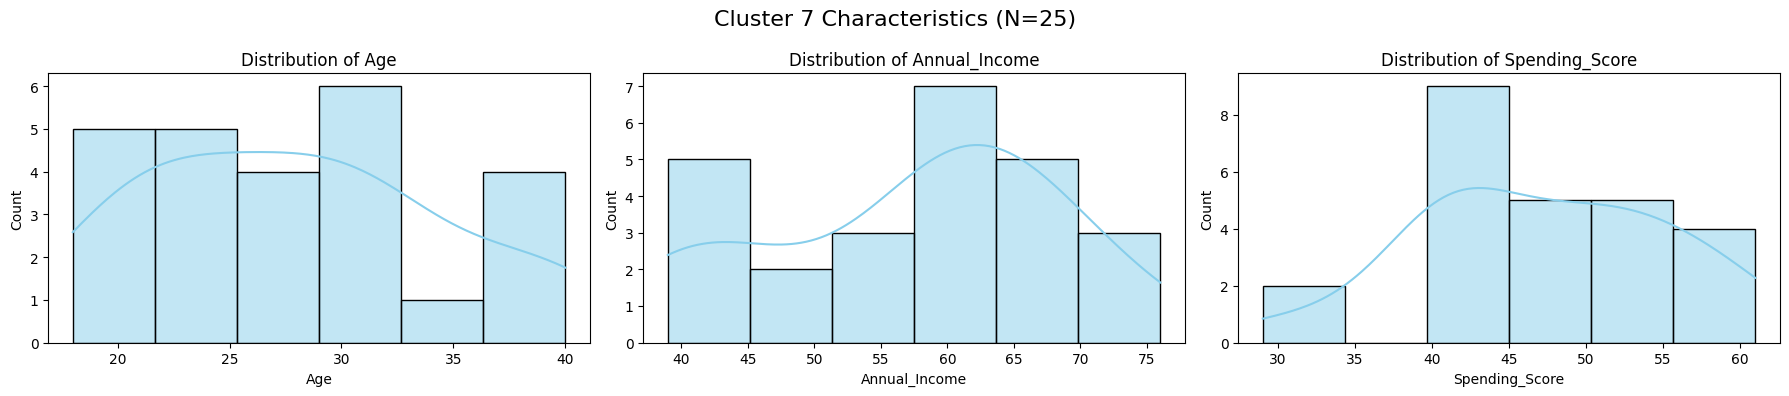

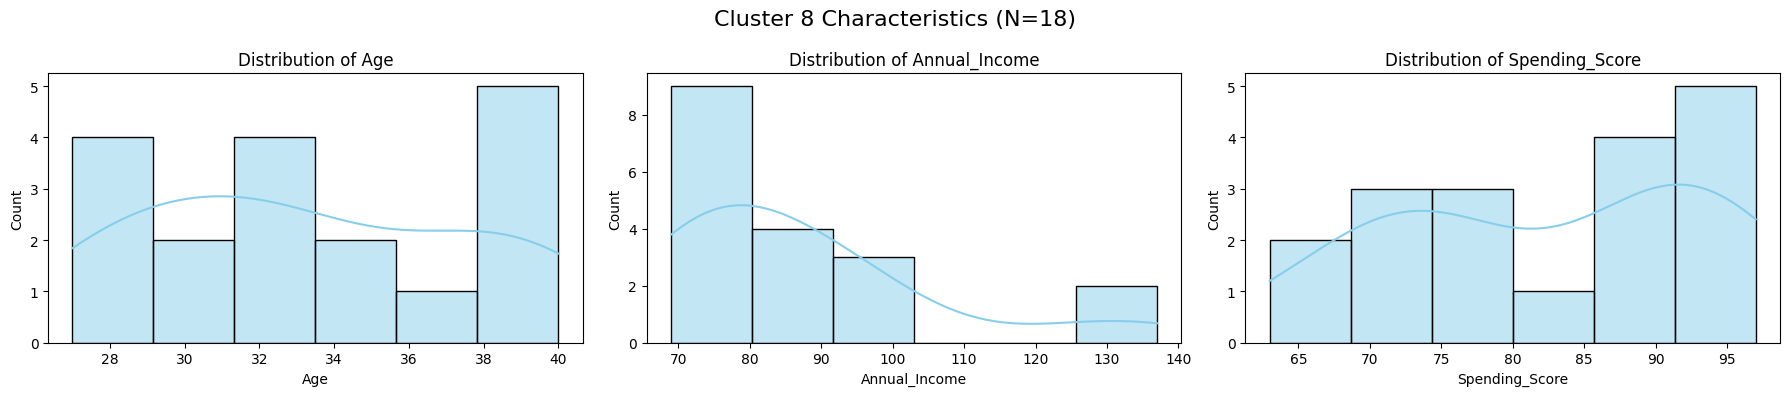

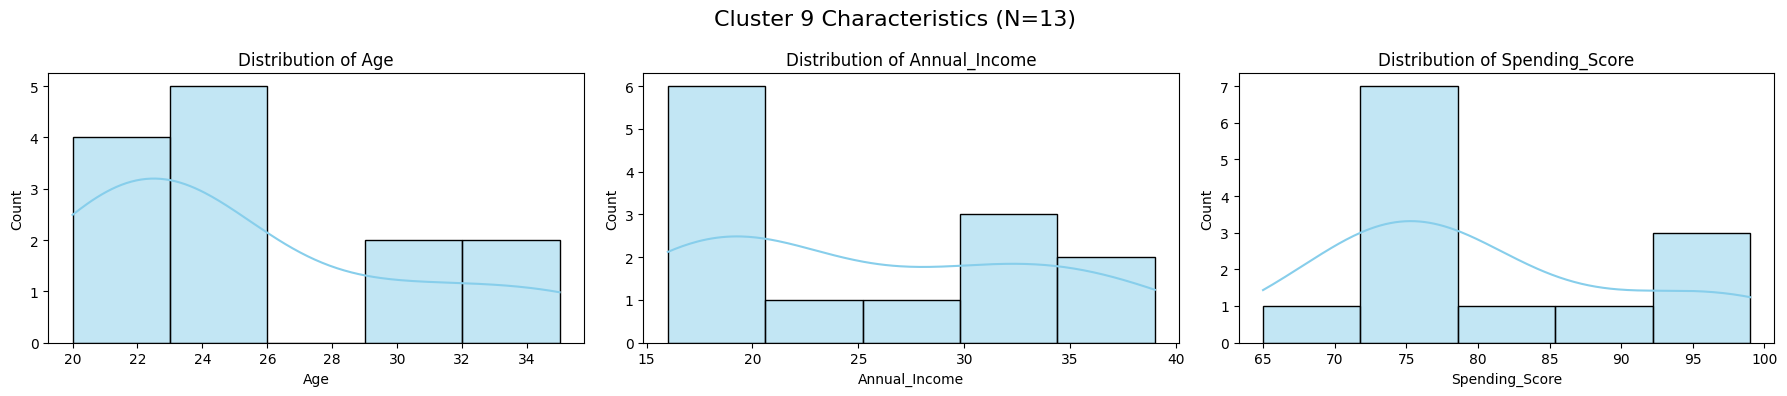

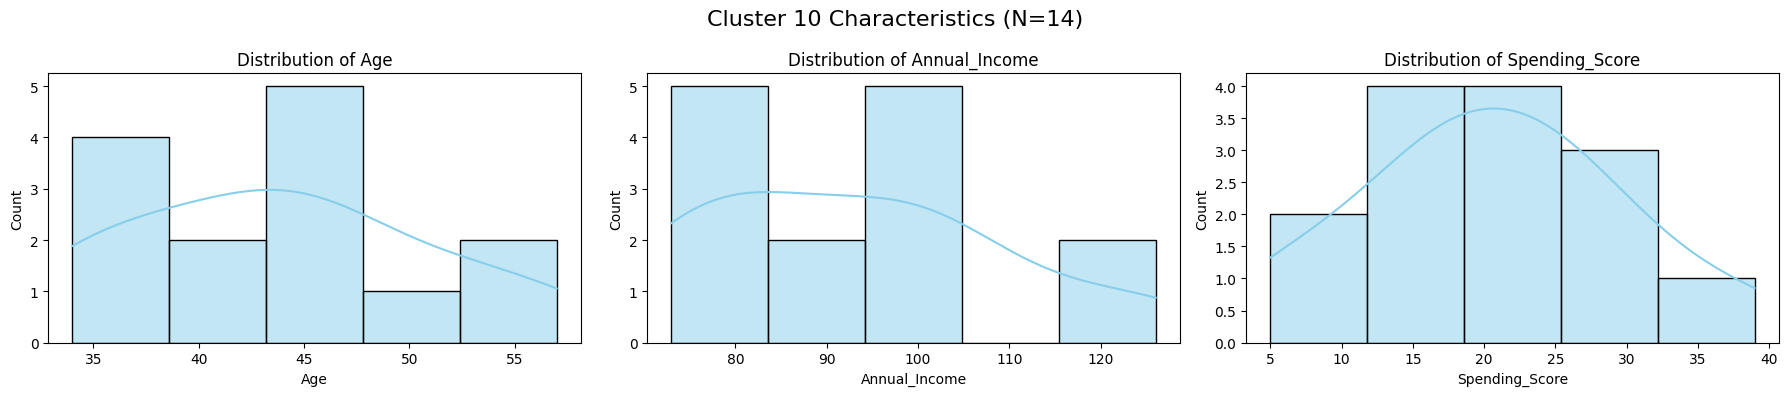

In [29]:
# Список колонок для анализа (без колонки Label)
features = ['Age', 'Annual_Income', 'Spending_Score']
unique_labels = sorted(df_kmean_result['Label'].unique())

for l in unique_labels:
    # Фильтруем данные для текущего кластера
    cluster_data = df_kmean_result[df_kmean_result['Label'] == l]
    
    # Создаем сетку графиков для признаков кластера
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'Cluster {l+1} Characteristics (N={len(cluster_data)})', fontsize=16)
    
    for i, col in enumerate(features):
        sns.histplot(cluster_data[col], ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
        
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_25973/1509361000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df_kmean_result, palette='viridis')
/tmp/ipykernel_25973/1509361000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df_kmean_result, palette='viridis')
/tmp/ipykernel_25973/1509361000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df_kmean_result, palette='viridis')


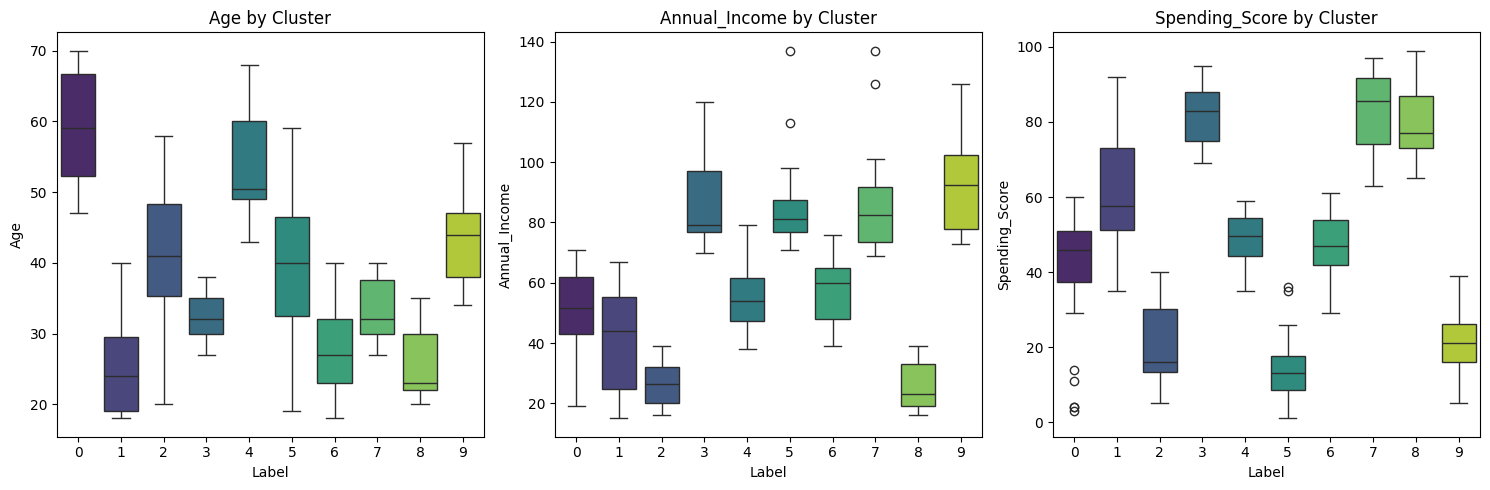

In [30]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Label', y=col, data=df_kmean_result, palette='viridis')
    plt.title(f'{col} by Cluster')

plt.tight_layout()
plt.show()

## 4) Agglomerative Clustering

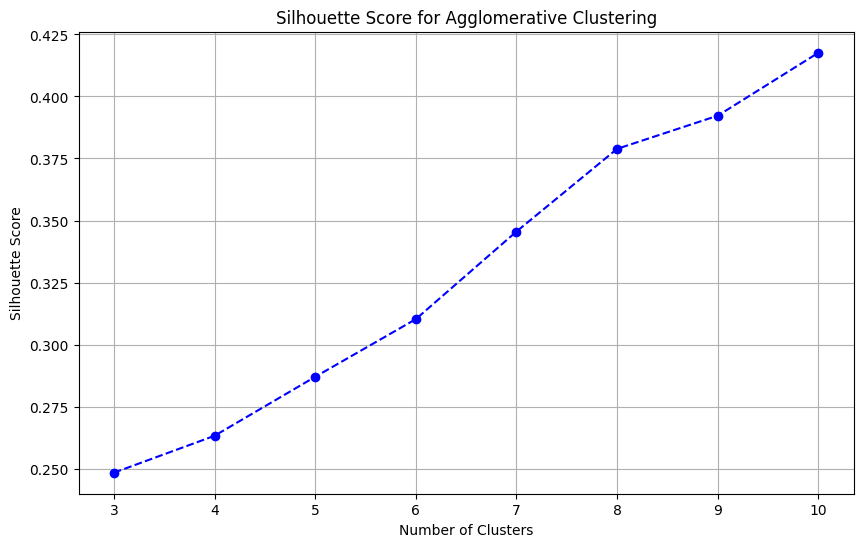

In [31]:
list_silhouette_scores = []

for n in list_K:
    model_aglo = AgglomerativeClustering(n_clusters=n)
    labels = model_aglo.fit_predict(X)
    
    score = silhouette_score(X, labels)
    list_silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(list_K, list_silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Score for Agglomerative Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(list_K)
plt.grid(True)
plt.show()

In [32]:
# пробуем разные комбинации 

linkages = ['ward', 'complete', 'average', 'single']
metrics = {'ward': ['euclidean'],  
           'complete': ['euclidean', 'manhattan'],
           'average': ['euclidean', 'manhattan'],
           'single': ['euclidean', 'manhattan']}

best_score = -1
best_config = None

for n in list_K:
    for linkage in linkages:
        for metric in metrics[linkage]:
            model = AgglomerativeClustering(n_clusters=n, linkage=linkage, metric=metric)
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_config = (linkage, metric)

print(f"\nЛучшая комбинация: linkage={best_config[0]}, metric={best_config[1]}, Silhouette={best_score:.4f}")


Лучшая комбинация: linkage=ward, metric=euclidean, Silhouette=0.4176


In [33]:
best_n = list_K[np.argmax(list_silhouette_scores)]
print(f"\nОптимальное количество кластеров: {best_n}")


Оптимальное количество кластеров: 10


#### Обучение AgglomerativeClustering для оптимального количество кластеров

In [34]:
model_agro = AgglomerativeClustering(best_n)
labels_agro = model_agro.fit_predict(X)

silhouette_score_agro = silhouette_score(X, labels_agro)
db_index_agro = davies_bouldin_score(X, labels_agro)
ch_index_agro = calinski_harabasz_score(X, labels_agro)

silhouette_score_agro

0.4176254448686808

In [35]:
df_result = update_df_result('AgglomerativeClustering', 
                            model_agro.n_clusters, 
                            X.shape[0]/model_agro.n_clusters, 
                            silhouette_score_agro,
                            db_index_agro,
                            ch_index_agro, 
                            model_agro.get_params()
                            )

In [36]:
df_agro_result = X.copy()
df_agro_result['Label'] = labels_agro

interpretation_cluster(df_agro_result)


--- Cluster 1 ---
Size: 29 customers
Avg Age: 1.3 years
Avg Income: $-0.4k
Avg Spending Score: -0.3
Avg Gender: 1.1 - 1(man), 0(women)

--- Cluster 2 ---
Size: 18 customers
Avg Age: -0.0 years
Avg Income: $1.0k
Avg Spending Score: -1.5
Avg Gender: 1.1 - 1(man), 0(women)

--- Cluster 3 ---
Size: 23 customers
Avg Age: -1.0 years
Avg Income: $-0.8k
Avg Spending Score: 0.4
Avg Gender: 1.1 - 1(man), 0(women)

--- Cluster 4 ---
Size: 25 customers
Avg Age: 1.1 years
Avg Income: $-0.3k
Avg Spending Score: -0.0
Avg Gender: -0.9 - 1(man), 0(women)

--- Cluster 5 ---
Size: 25 customers
Avg Age: -0.8 years
Avg Income: $-0.1k
Avg Spending Score: -0.1
Avg Gender: -0.9 - 1(man), 0(women)

--- Cluster 6 ---
Size: 18 customers
Avg Age: -0.4 years
Avg Income: $1.0k
Avg Spending Score: 1.3
Avg Gender: 1.1 - 1(man), 0(women)

--- Cluster 7 ---
Size: 21 customers
Avg Age: -0.5 years
Avg Income: $1.0k
Avg Spending Score: 1.2
Avg Gender: -0.9 - 1(man), 0(women)

--- Cluster 8 ---
Size: 15 customers
Avg Age:

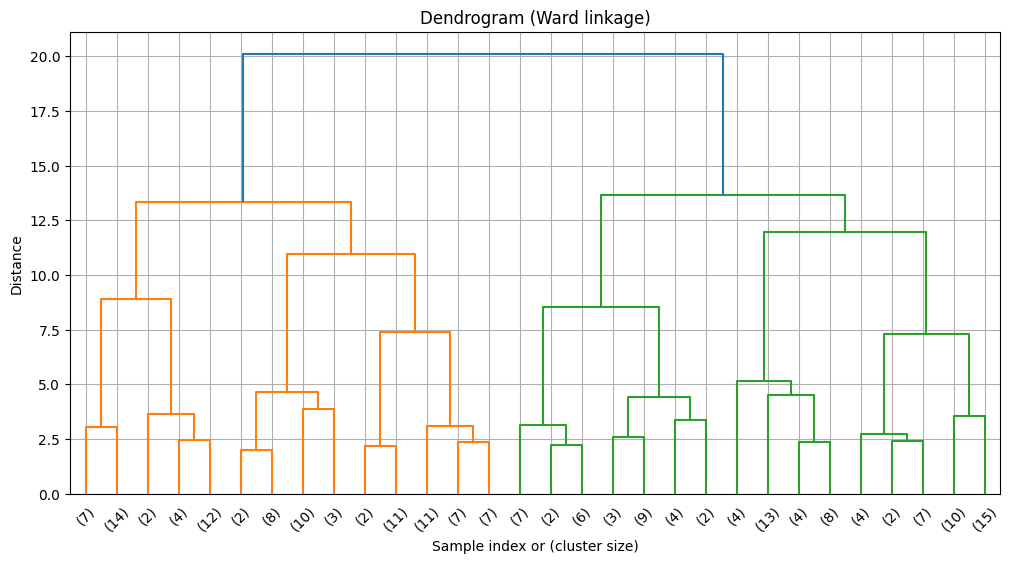

In [37]:
Z = scipy_linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dn = dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45., leaf_font_size=10.)
plt.title('Dendrogram (Ward linkage)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

## 5) DBSCAN


#### Метод «Локтя» для поиска eps (Эвристика k-расстояний)

In [38]:
# так как визуально данные не сильно зашумлены, возьмем n_features + 1
min_samples = df_norm.shape[1] + 1

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_norm)
distances, indices = neighbors_fit.kneighbors(df_norm)


distances = np.sort(distances[:, min_samples-1], axis=0)


fig = px.line(
    x=np.arange(len(distances)), 
    y=distances,
    labels={'x': 'Data Points (sorted)', 'y': f'{min_samples}-NN Distance (EPS)'},
    title='Interactive K-distance Graph'
)

fig.update_traces(mode='lines+markers', hovertemplate='Point Index: %{x}<br>EPS value: %{y:.4f}')
fig.update_layout(hovermode='x unified')

fig.show()


In [39]:
kl = KneeLocator(
    x=np.arange(len(distances)), 
    y=distances, 
    curve='convex', 
    direction='increasing'
)
best_eps = distances[kl.knee]  
print(f"best eps: {best_eps:.4f}")

best eps: 1.1079


In [40]:
model_dbscan_1 = DBSCAN(eps=best_eps, min_samples=min_samples)
labels_dbscan_1 = model_dbscan_1.fit_predict(X)

score_dbscan_1 = silhouette_score(X, labels_dbscan_1)
db_index_dbscan_1 = davies_bouldin_score(X, labels_dbscan_1)
ch_index_dbscan_1 = calinski_harabasz_score(X, labels_dbscan_1)
score_dbscan_1

0.258183307440165

In [41]:
n_clusters = len(set(labels_dbscan_1)) - (1 if -1 in labels_dbscan_1 else 0)
avg_freq = np.sum(labels_dbscan_1 != -1) / n_clusters if n_clusters > 0 else 0

df_result = update_df_result('DBSCAN_eblow', 
                            n_clusters, 
                            avg_freq, 
                            score_dbscan_1,
                            db_index_dbscan_1,
                            ch_index_dbscan_1, 
                            model_dbscan_1.get_params()
                            )


In [42]:
def plot_DBSCAN_result(best_eps, best_min_samples, mode='dbscan'):
    df = X.copy()

    if mode == 'dbscan':
        model = DBSCAN(eps=best_eps, min_samples=best_min_samples)
        
    elif mode == 'hdbscan':
        model = hdbscan.HDBSCAN(
            min_cluster_size=5,
            min_samples=best_min_samples,
            metric='euclidean'
        )

    labels = model.fit_predict(df_norm)
    df['Labels'] = labels

    plt.figure(figsize=(12, 8))

    # Создаем палитру, где для шума (-1) будет черный цвет
    unique_labels = np.unique(labels)
    colors = sns.color_palette("viridis", len(unique_labels) - (1 if -1 in unique_labels else 0))
    palette = {label: color for label, color in zip([l for l in unique_labels if l != -1], colors)}
    if -1 in unique_labels:
        palette[-1] = (0, 0, 0) # Черный для шума

    # Рисуем обычные кластеры
    sns.scatterplot(
        data=df[df['Labels'] != -1],
        x='Annual_Income', 
        y='Spending_Score', 
        hue='Labels', 
        palette=palette,
        legend='full',
        s=100,
        alpha=0.8
    )

    # Рисуем шум отдельным маркером (крестиками)
    sns.scatterplot(
        data=df[df['Labels'] == -1],
        x='Annual_Income', 
        y='Spending_Score', 
        color='black',
        marker='x',
        s=100,
        label='Noise'
    )

    plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='both', alpha=0.3)
    plt.show()

    # Выведем статистику
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Количество найденных кластеров: {n_clusters}")
    print(f"Количество точек шума: {n_noise} ({(n_noise/len(labels))*100:.1f}%)\n")


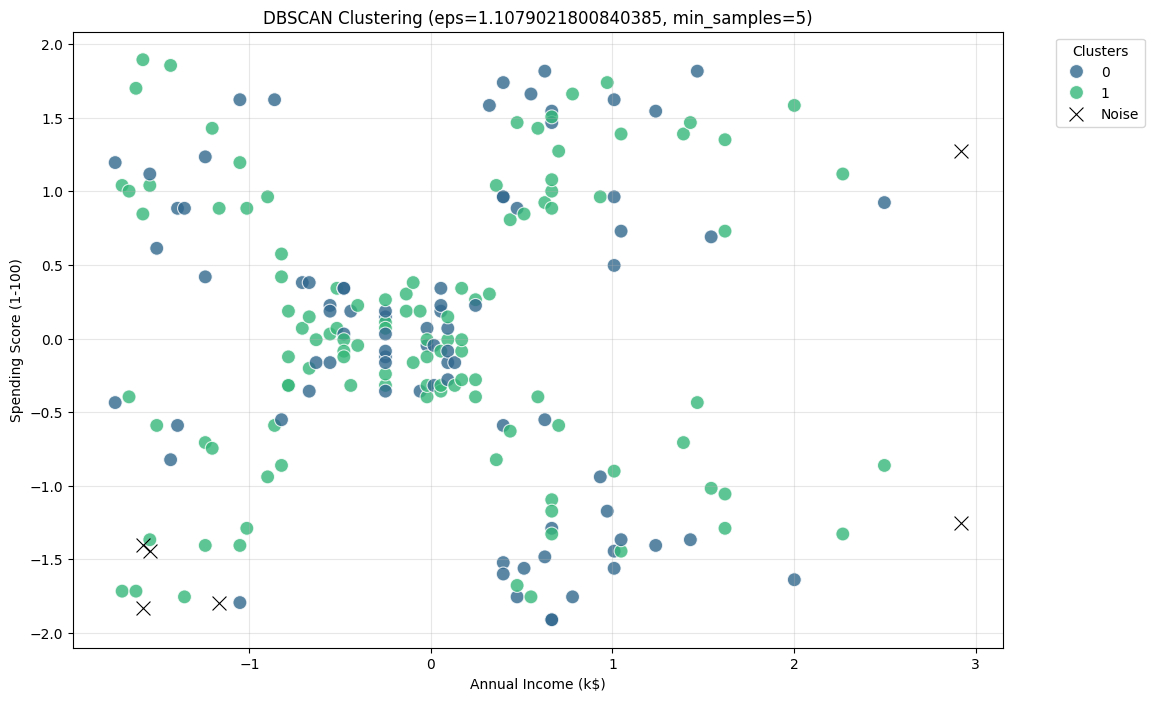

Количество найденных кластеров: 2
Количество точек шума: 6 (3.0%)



In [43]:
plot_DBSCAN_result(best_eps, min_samples)

#### Мало кластеров, большое расстояние или мало точек

пробуем дальше

In [44]:
eps_range = np.arange(0.05, 3, 0.05)
min_samples_range = range(3, 15)

results = []

for eps in eps_range:
    for ms in min_samples_range:
        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(df_norm)
        
        # Игнорируем шум
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            # Считаем силуэт скор только для не шумовых точек
            mask = labels != -1
            if np.sum(mask) > n_clusters: 
                score_dbscan = silhouette_score(df_norm[mask], labels[mask])
                db_index_dbscan = davies_bouldin_score(df_norm[mask], labels[mask])
                ch_index_dbscan = calinski_harabasz_score(df_norm[mask], labels[mask])
                results.append({'eps': eps, 'min_samples': ms, 'score': score_dbscan, 'db_index': db_index_dbscan, 'ch_index': ch_index_dbscan , 'clusters': n_clusters})

df_dbscan_res = pd.DataFrame(results)

# удалим варианты где n_cluster < 5 и n_cluster > 10
df_dbscan_res = df_dbscan_res[(df_dbscan_res['clusters'] >= 5) & (df_dbscan_res['clusters'] <= 10)]

print(df_dbscan_res.sort_values(by='score', ascending=False).head(10))


     eps  min_samples     score  db_index    ch_index  clusters
0   0.20            3  0.766768  0.275067  405.464223         7
15  0.45            5  0.658387  0.447104  125.640827         6
14  0.45            4  0.643992  0.449331  121.785923         9
9   0.40            4  0.637168  0.457505  121.248124         8
22  0.50            6  0.629881  0.507287  111.562057         5
31  0.55            7  0.626796  0.508971  146.450816         5
52  0.65            9  0.613604  0.540384  147.729871         6
53  0.65           10  0.611196  0.561815  151.851811         5
6   0.35            4  0.609676  0.554477  103.763578         8
29  0.55            5  0.573170  0.555553  120.420100         8


#### Топ 3 по silhouette_score

Тест параметров по silhouette_score №0: Score = 0.7668, Clusters = 7


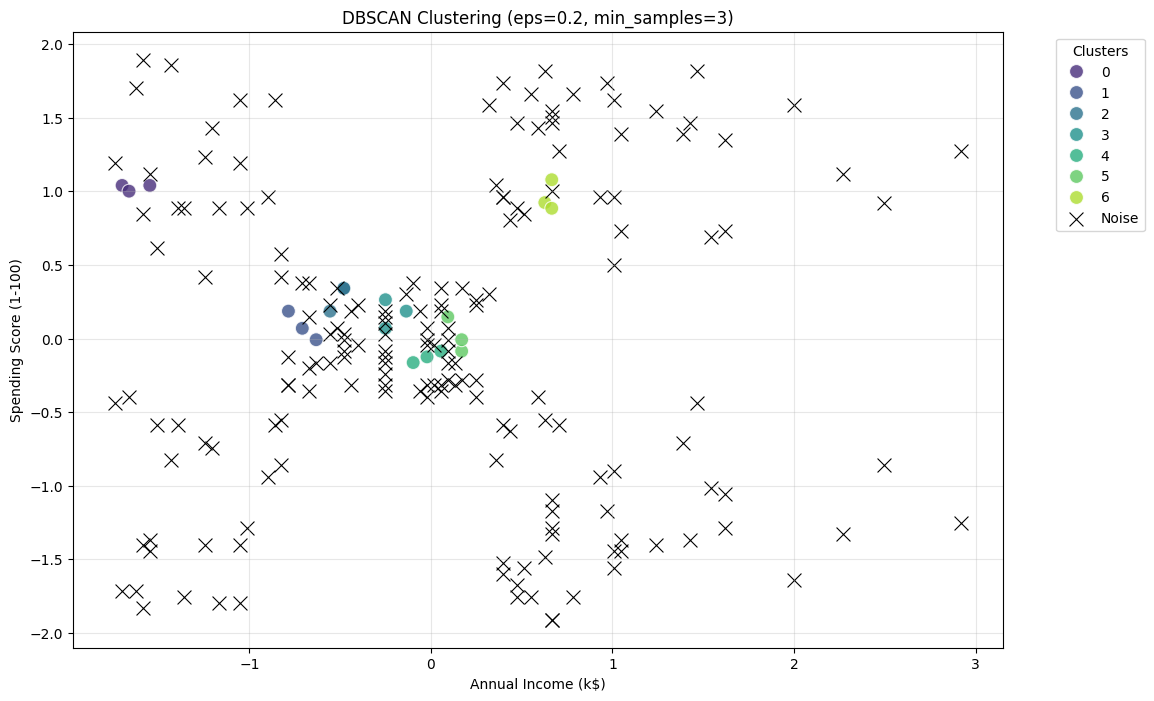

Количество найденных кластеров: 7
Количество точек шума: 179 (89.5%)

Тест параметров по silhouette_score №15: Score = 0.6584, Clusters = 6


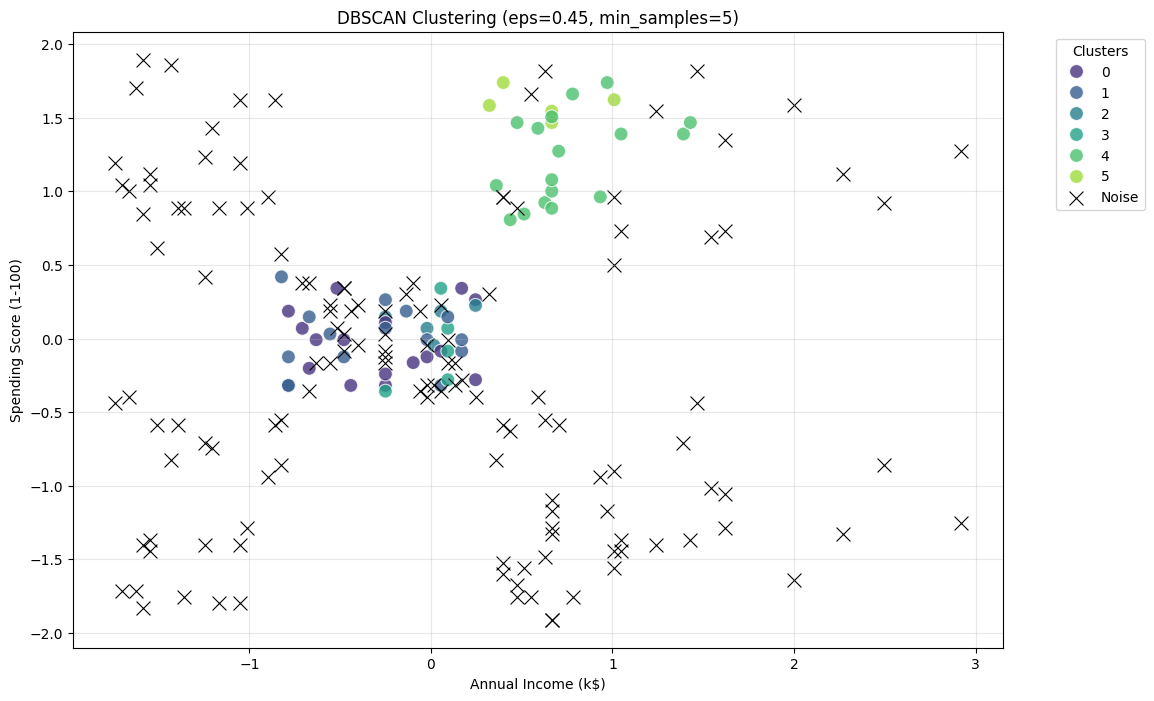

Количество найденных кластеров: 6
Количество точек шума: 137 (68.5%)

Тест параметров по silhouette_score №14: Score = 0.6440, Clusters = 9


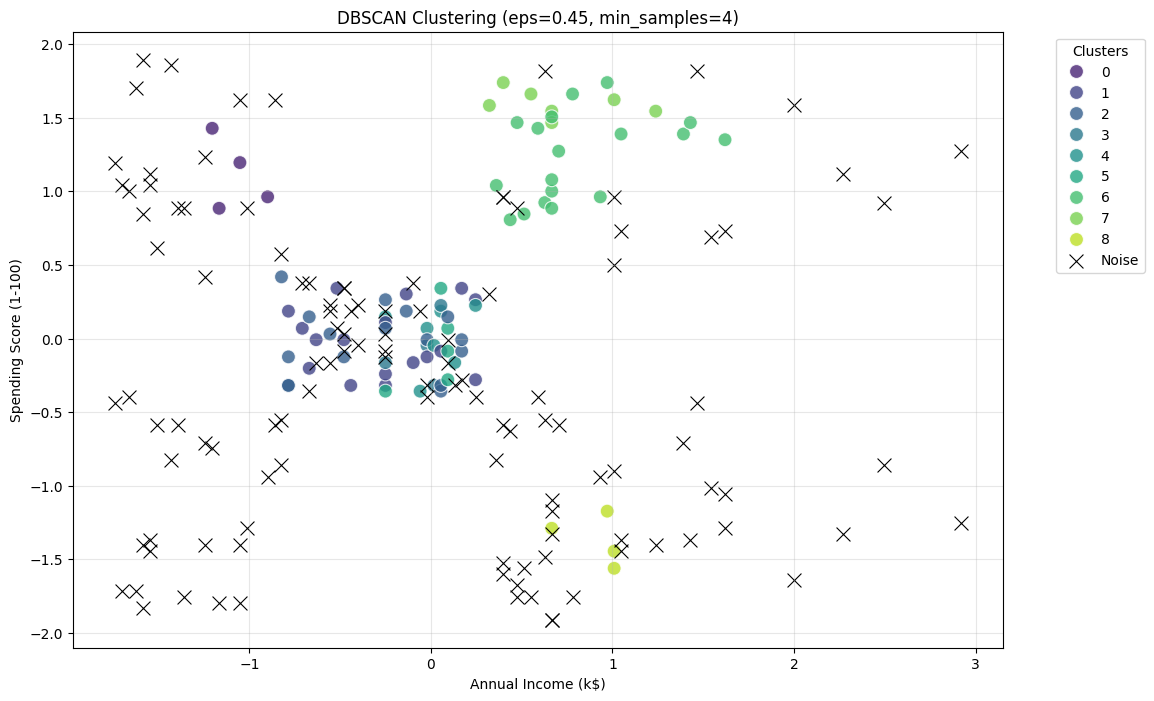

Количество найденных кластеров: 9
Количество точек шума: 118 (59.0%)



In [45]:
top_n = 3

for index, row in df_dbscan_res.sort_values(by='score', ascending=False).head(top_n).iterrows():
    # Перебор + отрисовка
    current_eps = row['eps']
    current_min_samples = int(row['min_samples'])
    current_score = row['score']
    
    print(f"Тест параметров по silhouette_score №{index}: Score = {current_score:.4f}, Clusters = {int(row['clusters'])}")
    
    plot_DBSCAN_result(current_eps, current_min_samples)

    # сохраняям релуьтаты
    df_result = update_df_result('DBSCAN', 
                                row['clusters'], 
                                None, 
                                row['score'],
                                row['db_index'],
                                row['ch_index'], 
                                [row['eps'], row['min_samples']]
                                )


Алгоримт индефицирует много точек как шум

### HDBSCAN

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) — алгоритм кластеризации, который основан на идее о том, что кластеры — это области высокой плотности, разделённые областями низкой плотности. Это расширение алгоритма DBSCAN. 

In [46]:
results = []
for min_cluster_size in range(5, 50):  
    for min_samples in range(3, min_cluster_size + 1):
        model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric='euclidean'
        )
        labels = model.fit_predict(df_norm)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        mask = labels != -1
        if np.sum(mask) > n_clusters:
            score = silhouette_score(df_norm[mask], labels[mask])
            db = davies_bouldin_score(df_norm[mask], labels[mask])
            ch = calinski_harabasz_score(df_norm[mask], labels[mask])
            results.append({
                'eps': None,
                'min_samples': min_samples,
                'score': score,
                'db_index': db,
                'ch_index': ch,
                'clusters': n_clusters
            })

df_hdbscan_res = pd.DataFrame(results)
df_hdbscan_res.sort_values(by='score', ascending=False).head(10)

,eps,min_samples,score,db_index,ch_index,clusters
491,None,32,0.360547,1.188548,56.133146,2
461,None,32,0.360547,1.188548,56.133146,2
490,None,31,0.358829,1.211759,58.685063,2
460,None,31,0.358829,1.211759,58.685063,2
549,None,31,0.358829,1.211759,58.685063,2
431,None,31,0.358829,1.211759,58.685063,2
578,None,31,0.358829,1.211759,58.685063,2
520,None,31,0.358829,1.211759,58.685063,2
577,None,30,0.354855,1.232501,59.478925,2
489,None,30,0.354855,1.232501,59.478925,2


Тест параметров по silhouette_score №491: Score = 0.3605, Clusters = 2


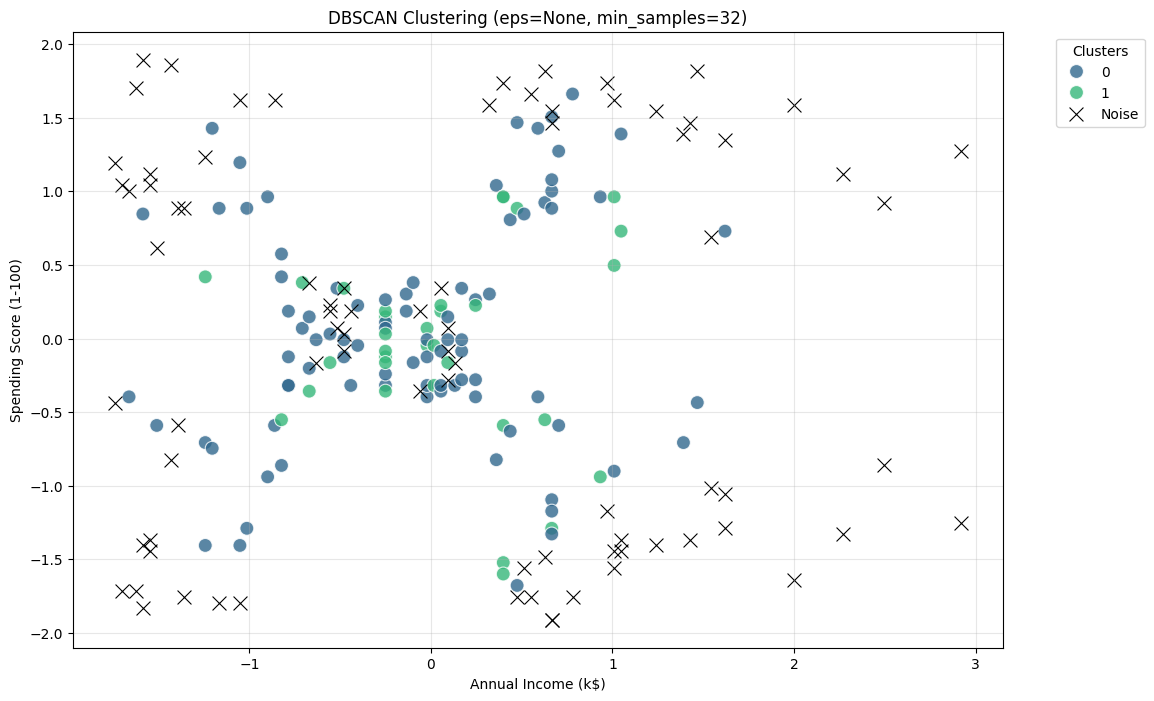

Количество найденных кластеров: 2
Количество точек шума: 81 (40.5%)

Тест параметров по silhouette_score №461: Score = 0.3605, Clusters = 2


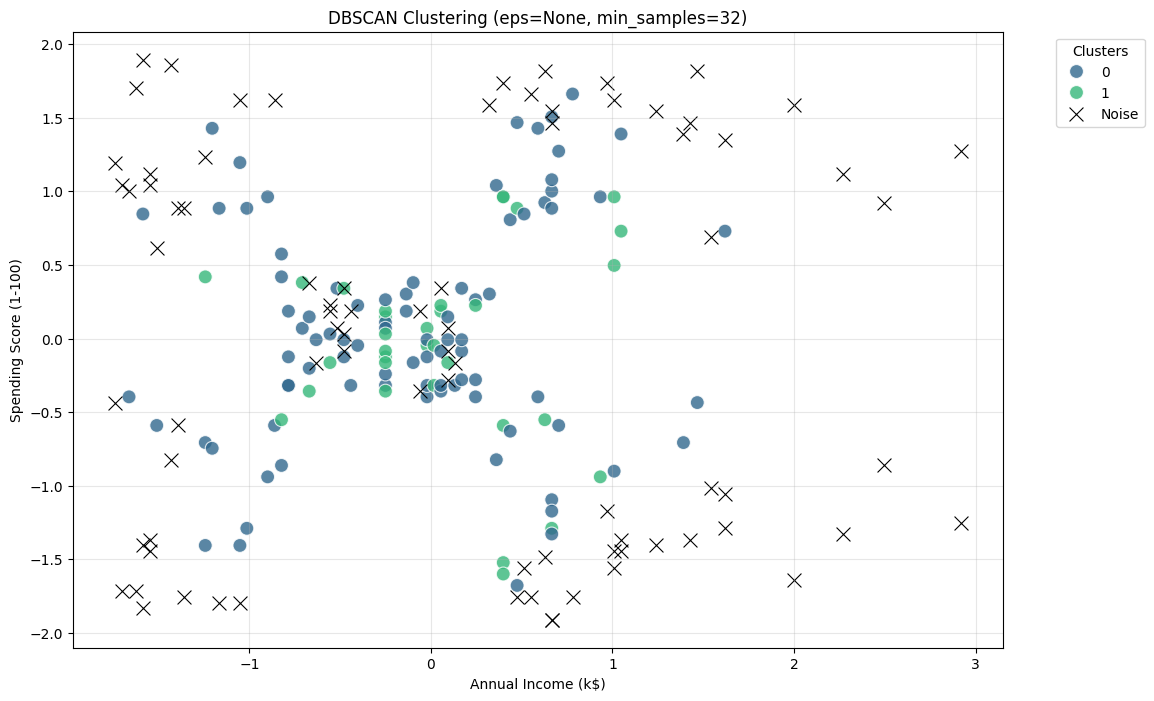

Количество найденных кластеров: 2
Количество точек шума: 81 (40.5%)

Тест параметров по silhouette_score №490: Score = 0.3588, Clusters = 2


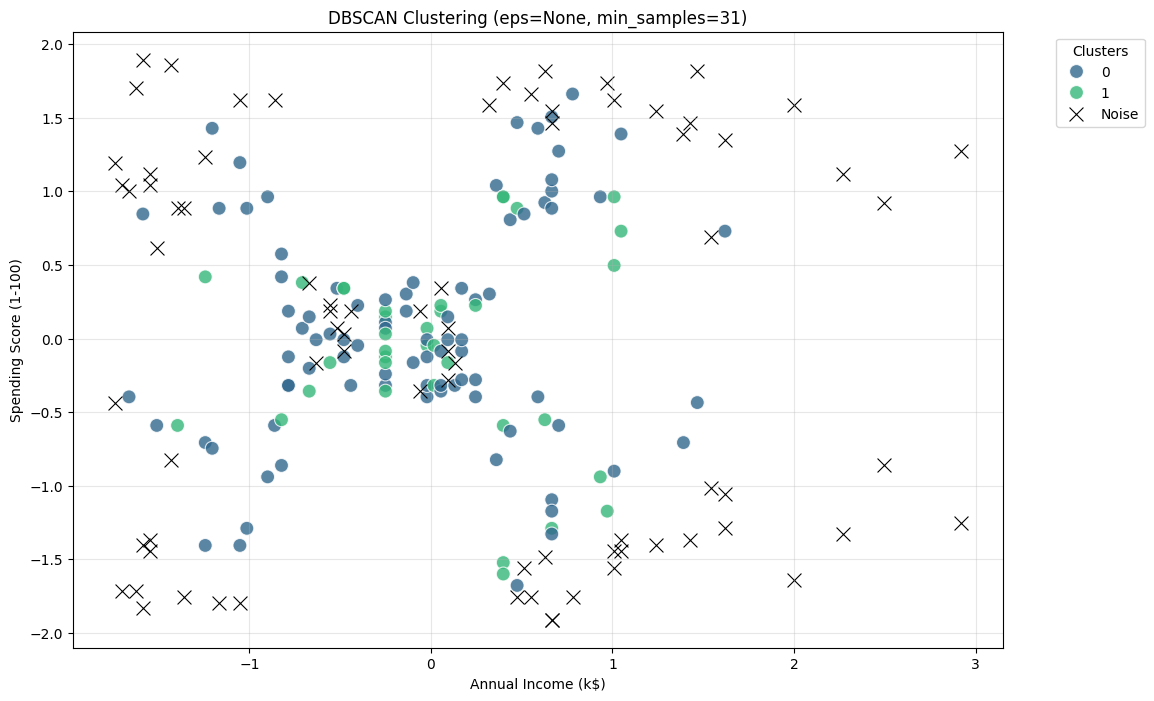

Количество найденных кластеров: 2
Количество точек шума: 78 (39.0%)



In [47]:
top_n = 3

for index, row in df_hdbscan_res.sort_values(by='score', ascending=False).head(top_n).iterrows():
    # Перебор + отрисовка
    current_eps = row['eps']
    current_min_samples = int(row['min_samples'])
    current_score = row['score']
    
    print(f"Тест параметров по silhouette_score №{index}: Score = {current_score:.4f}, Clusters = {int(row['clusters'])}")
    
    plot_DBSCAN_result(current_eps, current_min_samples, 'hdbscan')

    # сохраняям релуьтаты
    df_result = update_df_result('HDBSCAN', 
                                row['clusters'], 
                                None, 
                                row['score'],
                                row['db_index'],
                                row['ch_index'], 
                                [row['eps'], row['min_samples']]
                                )

## 6) Сравнение результатов

In [48]:
df_result.sort_values(by='Silhouette_score', ascending=False)

,Algoritm,N_clusters,Avg_frequens,Silhouette_score,DB-index,CH-index,Params
3,DBSCAN,7.0,None,0.766768,0.275067,405.464223,"[0.2, 3.0]"
4,DBSCAN,6.0,None,0.658387,0.447104,125.640827,"[0.45, 5.0]"
5,DBSCAN,9.0,None,0.643992,0.449331,121.785923,"[0.45, 4.0]"
0,kmeans,10,20.0,0.420764,0.833103,89.978196,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."
1,AgglomerativeClustering,10,20.0,0.417625,0.824712,87.611306,"{'compute_distances': False, 'compute_full_tre..."
6,HDBSCAN,2,None,0.360547,1.188548,56.133146,"[None, 32]"
7,HDBSCAN,2,None,0.360547,1.188548,56.133146,"[None, 32]"
8,HDBSCAN,2,None,0.358829,1.211759,58.685063,"[None, 31]"
2,DBSCAN_eblow,2,97.0,0.258183,2.704162,35.300456,"{'algorithm': 'auto', 'eps': 1.107902180084038..."


DBSCAN - не подходит, так как много шумовых точек

In [49]:
best_params = df_result[df_result['Algoritm'] == 'kmeans'].sort_values('Silhouette_score', ascending=False).iloc[0]['Params']
best_model = KMeans(**best_params)
label = best_model.fit_predict(X)

df_cluster = pd.DataFrame(df, columns=['Age', 'Annual_Income', 'Spending_Score', 'Gender'])
df_cluster['Label'] = label

In [50]:
df_cluster['Label'].value_counts()

Label
4    26
0    26
6    25
1    24
3    21
5    19
7    18
2    14
9    14
8    13
Name: count, dtype: int64

/tmp/ipykernel_25973/4187911619.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_25973/4187911619.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


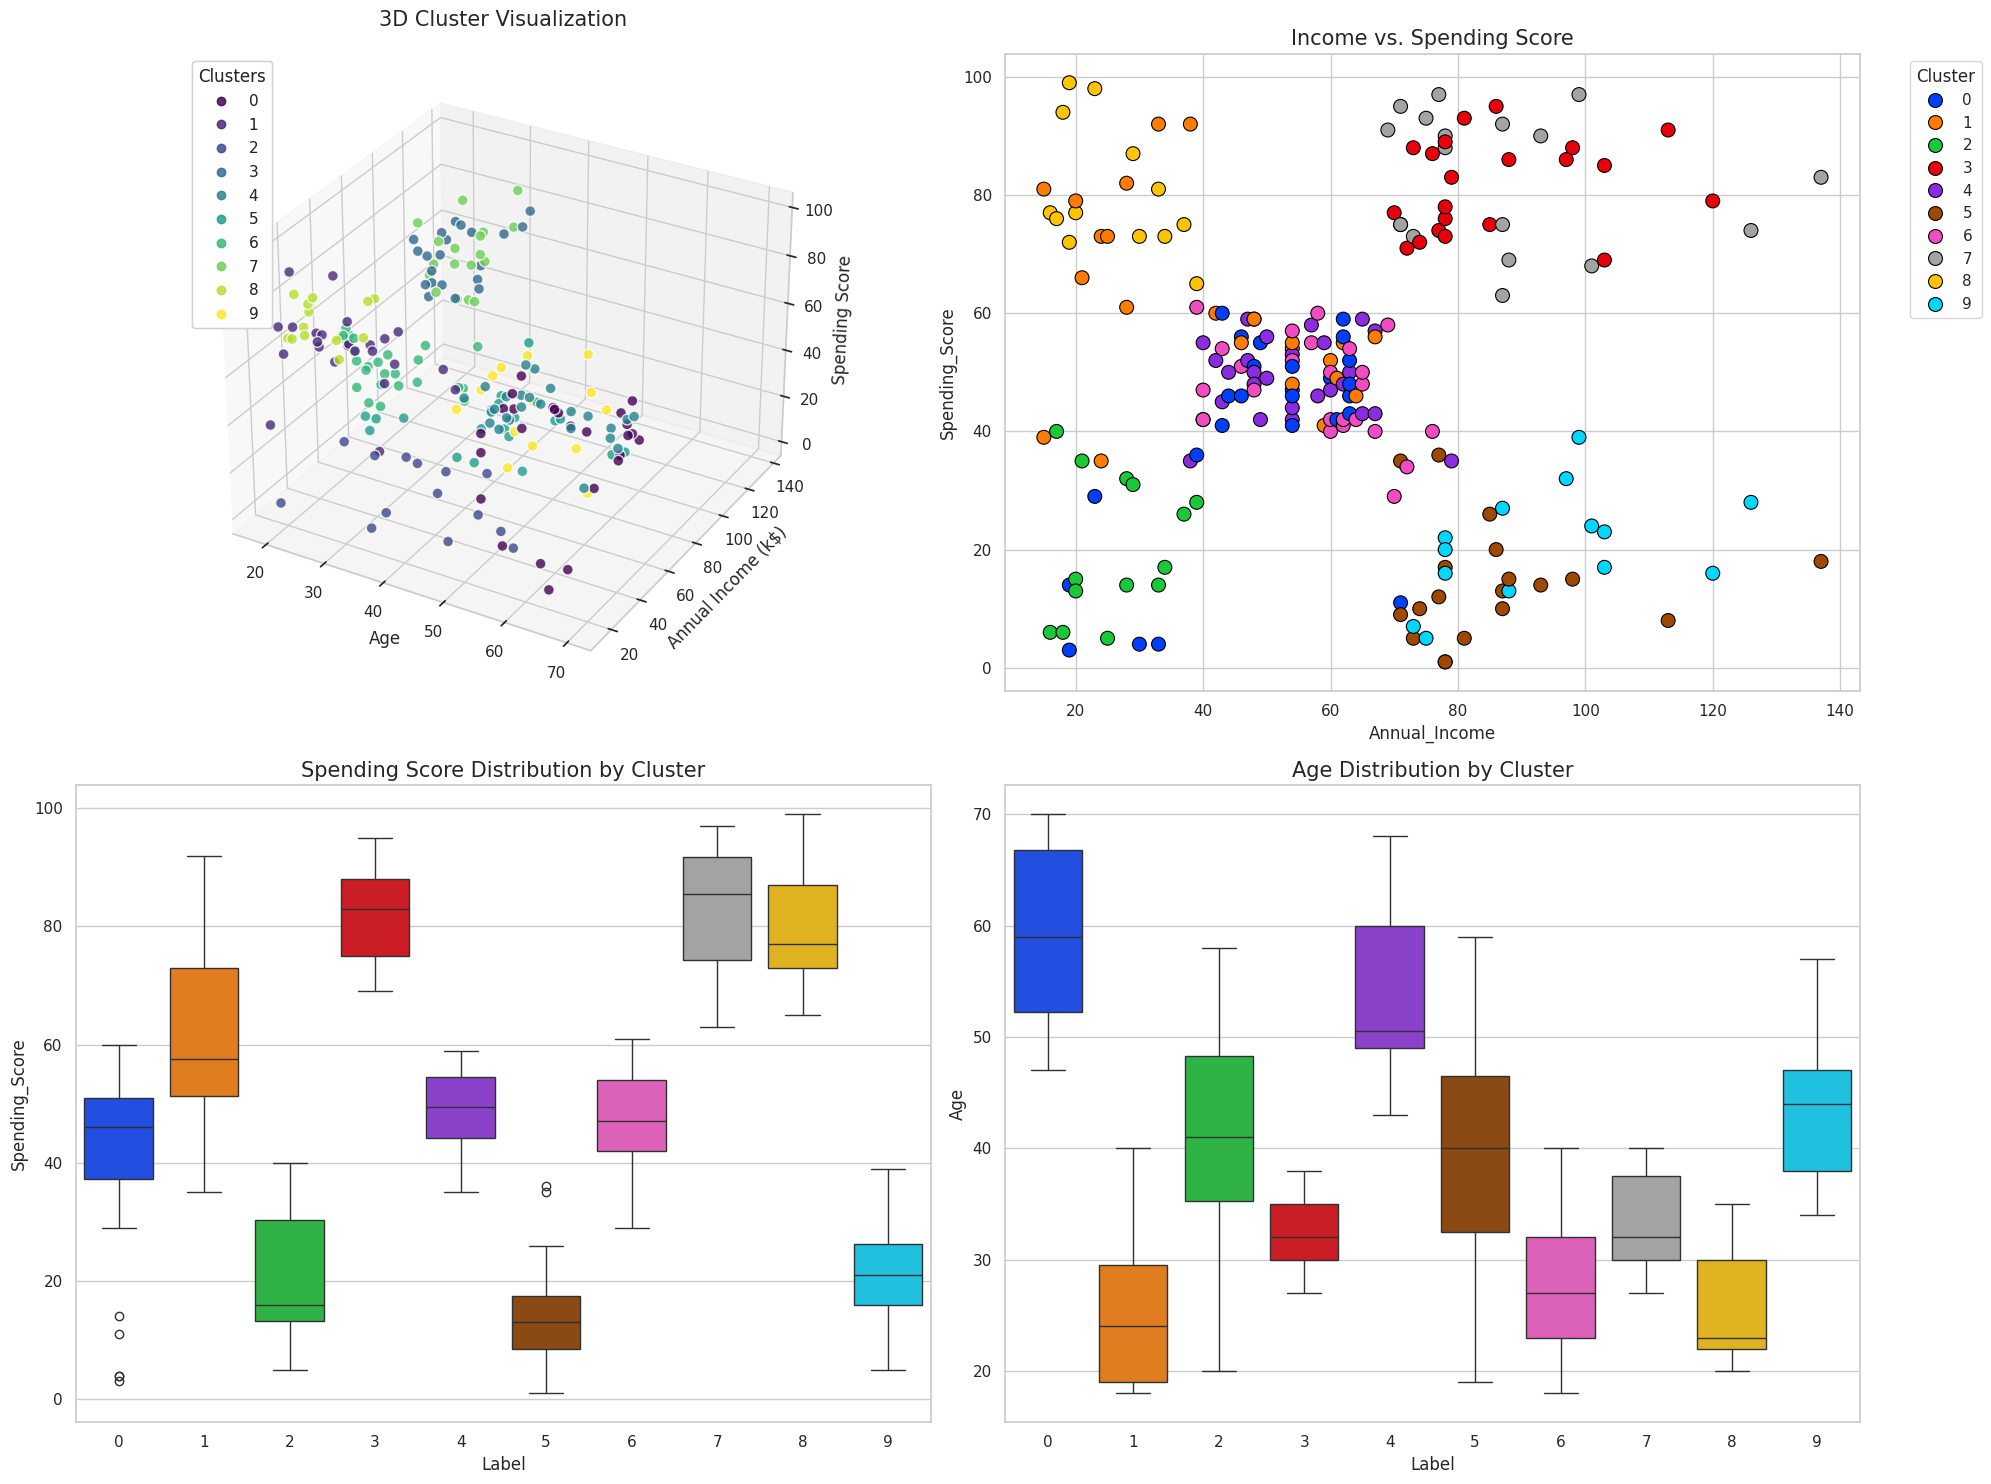

In [55]:
import os

sns.set_theme(style="whitegrid")
palette = sns.color_palette("bright", n_colors=df_cluster['Label'].nunique())

fig = plt.figure(figsize=(20, 15))

# 1. 3D Scatter Plot (Age, Income, Spending Score)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
scatter = ax1.scatter3D(
    df_cluster['Age'], 
    df_cluster['Annual_Income'], 
    df_cluster['Spending_Score'], 
    c=df_cluster['Label'], 
    cmap='viridis', 
    s=60, 
    edgecolor='w', 
    alpha=0.8
)
ax1.set_xlabel('Age')
ax1.set_ylabel('Annual Income (k$)')
ax1.set_zlabel('Spending Score')
ax1.set_title('3D Cluster Visualization', fontsize=15, pad=20)
legend1 = ax1.legend(*scatter.legend_elements(), title="Clusters", loc="upper left")
ax1.add_artist(legend1)

# 2. 2D Scatter: Annual Income vs Spending Score
ax2 = fig.add_subplot(2, 2, 2)
sns.scatterplot(
    data=df_cluster, 
    x='Annual_Income', 
    y='Spending_Score', 
    hue='Label', 
    palette=palette, 
    s=100, 
    ax=ax2, 
    edgecolor='black'
)
ax2.set_title('Income vs. Spending Score', fontsize=15)
ax2.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Boxplot: Spending Score по кластерам
ax3 = fig.add_subplot(2, 2, 3)
sns.boxplot(
    data=df_cluster, 
    x='Label', 
    y='Spending_Score', 
    palette=palette, 
    ax=ax3
)
ax3.set_title('Spending Score Distribution by Cluster', fontsize=15)

# 4. Boxplot: Возраст по кластерам
ax4 = fig.add_subplot(2, 2, 4)
sns.boxplot(
    data=df_cluster, 
    x='Label', 
    y='Age', 
    palette=palette, 
    ax=ax4
)
ax4.set_title('Age Distribution by Cluster', fontsize=15)

os.makedirs("reports/figures", exist_ok=True)
plt.savefig("reports/figures/cluster_visualization.png", dpi=150, bbox_inches='tight')

plt.tight_layout()


## 7) Интерпретация сегментов

In [52]:
interpretation_cluster(df_cluster)


--- Cluster 1 ---
Size: 26 customers
Avg Age: 58.8 years
Avg Income: $48.7k
Avg Spending Score: 39.8
Avg Gender: 1.0 - 1(man), 0(women)

--- Cluster 2 ---
Size: 24 customers
Avg Age: 25.2 years
Avg Income: $41.2k
Avg Spending Score: 60.9
Avg Gender: 1.0 - 1(man), 0(women)

--- Cluster 3 ---
Size: 14 customers
Avg Age: 41.2 years
Avg Income: $26.1k
Avg Spending Score: 20.1
Avg Gender: 0.1 - 1(man), 0(women)

--- Cluster 4 ---
Size: 21 customers
Avg Age: 32.2 years
Avg Income: $86.0k
Avg Spending Score: 81.7
Avg Gender: 0.0 - 1(man), 0(women)

--- Cluster 5 ---
Size: 26 customers
Avg Age: 54.2 years
Avg Income: $54.2k
Avg Spending Score: 49.0
Avg Gender: 0.0 - 1(man), 0(women)

--- Cluster 6 ---
Size: 19 customers
Avg Age: 38.5 years
Avg Income: $85.9k
Avg Spending Score: 14.2
Avg Gender: 1.0 - 1(man), 0(women)

--- Cluster 7 ---
Size: 25 customers
Avg Age: 28.0 years
Avg Income: $57.4k
Avg Spending Score: 47.1
Avg Gender: 0.0 - 1(man), 0(women)

--- Cluster 8 ---
Size: 18 customers
Avg

In [53]:
summary = df_cluster.groupby('Label').agg(
    Size=('Age', 'count'),                
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean'),
    Most_Common_Gender=('Gender', lambda x: "Man" if x.mode()[0] == 1 else "Woman")
).round(1)

display(summary)

,Size,Avg_Age,Avg_Income,Avg_Spending,Most_Common_Gender
Label,,,,,
0,26,58.8,48.7,39.8,Man
1,24,25.2,41.2,60.9,Man
2,14,41.2,26.1,20.1,Woman
3,21,32.2,86.0,81.7,Woman
4,26,54.2,54.2,49.0,Woman
5,19,38.5,85.9,14.2,Man
6,25,28.0,57.4,47.1,Woman
7,18,33.3,87.1,82.7,Man
8,13,25.5,25.7,80.5,Woman


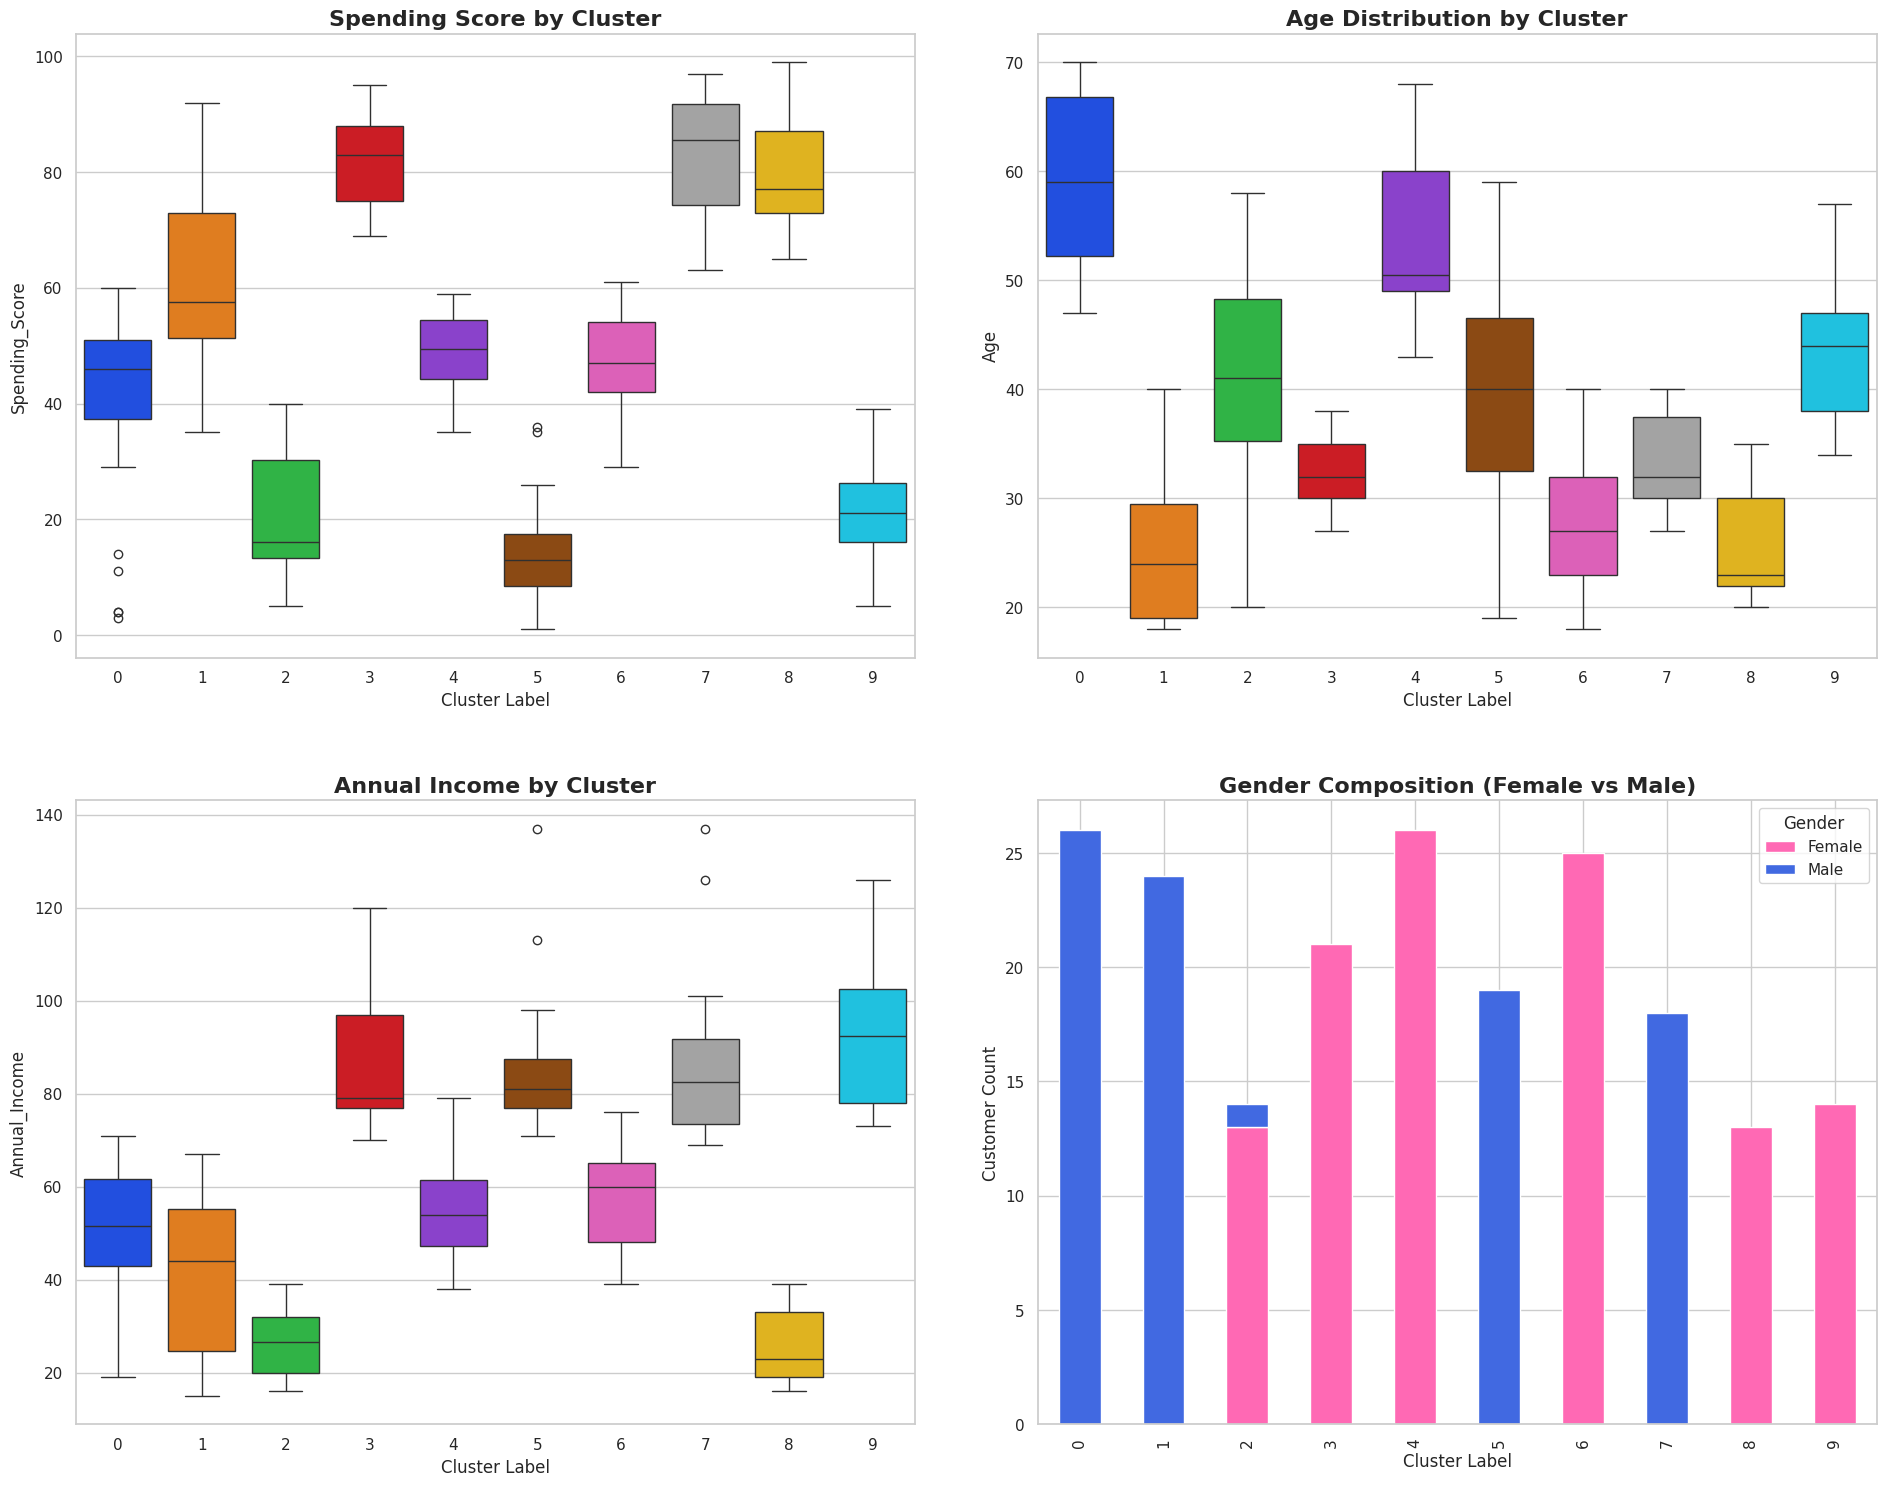

In [54]:
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid")

palette = sns.color_palette("bright", n_colors=df_cluster['Label'].nunique())
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Boxplot: Spending Score (Траты)
sns.boxplot(data=df_cluster, x='Label', y='Spending_Score', palette=palette, hue='Label', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Spending Score by Cluster', fontsize=16, fontweight='bold')
axes[0, 0].set_xlabel('Cluster Label')

# 2. Boxplot: Возраст
sns.boxplot(data=df_cluster, x='Label', y='Age', palette=palette, hue='Label', ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Age Distribution by Cluster', fontsize=16, fontweight='bold')
axes[0, 1].set_xlabel('Cluster Label')

# 3. Boxplot: Годовой доход
sns.boxplot(data=df_cluster, x='Label', y='Annual_Income', palette=palette, hue='Label', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Annual Income by Cluster', fontsize=16, fontweight='bold')
axes[1, 0].set_xlabel('Cluster Label')

# 4. Gender composition
gender_counts = df_cluster.groupby(['Label', 'Gender']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#FF69B4', '#4169E1'])
axes[1, 1].set_title('Gender Composition (Female vs Male)', fontsize=16, fontweight='bold')
axes[1, 1].set_xlabel('Cluster Label')
axes[1, 1].set_ylabel('Customer Count')
axes[1, 1].legend(title='Gender', labels=['Female', 'Male'], loc='upper right')

plt.tight_layout(pad=4.0)
plt.show()


### 📊 Интерпретация сегментов покупателей

1. **🟦Кластер 1 (58.8 лет, $48.7k, Spending_Score - 39.8, Мужчины)** — «Зрелые прагматики» → Совершают редкие, но запланированные покупки (Пример - техника, товары для дома/хобби), ценят надежность.

2. **🟧Кластер 2 (25.2 года, $41.2k, Spending_Score - 60.9, Мужчины)** — «Молодые модники» → Активно тратят (Пример - гаджеты, кроссовки и развлечения), самая восприимчивая к новинкам мужская группа.

3. **🟩Кластер 3 (41.2 года, $26.1k, Spending_Score - 20.1, преимущ. Женщины)** — «Экономные хозяйки» → Рациональное потребление, фокус на товарах первой необходимости и семейном бюджете.

4. **🟥Кластер 4 (32.2 года, $86.0k, Spending_Score - 81.7, Женщины)** — «Любительницы роскоши» → Главная целевая аудитория для брендовой одежды, косметики и ювелирных изделий; высокий потенциал для VIP-маркетинга.

5. **🟪Кластер 5 (54.2 года, $54.2k, Spending_Score - 49.0, Женщины)** — «Заботливые домохозяйки» → Зрелые женщины со стабильными привычками, фокус на товарах для дома, уюта и подарках близким.

6. **🟫Кластер 6 (38.5 лет, $85.9k, Spending_Score - 14.2, Мужчины)** — «Состоятельные мизантропы» → Мужчины с высоким доходом, которые не любят шоппинг; только редкие конкретные дорогие покупки.

7. **🟪Кластер 7 (28.0 лет, $57.4k, Spending_Score - 47.1, Женщины)** — «Рациональные миллениалы» → Современные работающие женщины, соблюдают баланс между модой и полезностью вещей.

8. **⬜Кластер 8 (33.3 года, $87.1k, Spending_Score - 82.7, Мужчины)** — «Успешные гедонисты» → Мужчины-карьеристы с высокими запросами; тратят на лайфстайл (Пример - дорогие часы, аксессуары и премиум-сервисы).

9. **🟨Кластер 9 (25.5 лет, $25.7k, Spending_Score - 80.5, Женщины)** — «Импульсивные студентки» → Тратят почти весь доход (или бюджет родителей) (Пример - косметику и одежду)

10. **💠Кластер 10 (43.8 года, $93.3k, Spending_Score - 20.6, Женщины)** — «Успешные и избирательные» → Женщины с очень высоким доходом, предпочитающие качество количеству; их интересует эксклюзивность и спокойный шоппинг.